In [20]:
# Install PyTorch, torchvision, scikit-learn, and plotting libraries
!pip install -q torch torchvision timm scikit-learn matplotlib seaborn pillow tqdm

In [21]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import joblib

# Make the results reproducible
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Use GPU if available, otherwise fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [22]:
# This notebook is designed for Kaggle. On Kaggle the dataset is mounted as input,
# so we just need to find the folder that contains the class sub-directories.
candidate_paths = [
    '/kaggle/input/eye-diseases-classification',
    '/kaggle/input/eye-diseases-classification/Dataset/Dataset X',
    '/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification',
    '/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/Dataset/Dataset X',
]

DATASET_PATH = None
for path in candidate_paths:
    if os.path.exists(path):
        DATASET_PATH = path
        break

# If we found a root that doesn't already hold the class folders,
# descend into the first sub-directory that does (e.g. "Dataset/Dataset X").
if DATASET_PATH is not None:
    entries = os.listdir(DATASET_PATH)
    class_names = {'cataract', 'diabetic_retinopathy', 'glaucoma', 'normal'}
    if not (set(entries) & class_names):
        for sub in sorted(entries):
            sub_path = os.path.join(DATASET_PATH, sub)
            if os.path.isdir(sub_path):
                DATASET_PATH = sub_path
                break

if DATASET_PATH is None:
    raise FileNotFoundError(
        'Dataset not found.\n'
        'Run this notebook on Kaggle and add the dataset\n'
        '"eye-diseases-classification" by gunavenkatdoddi as a data source.\n'
        'Then re-run the cell.'
    )

print('Dataset folder found:', DATASET_PATH)
print('Top-level entries:', os.listdir(DATASET_PATH)[:10])

Dataset folder found: /kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset
Top-level entries: ['glaucoma', 'normal', 'diabetic_retinopathy', 'cataract']


In [23]:
# Resize and normalize images so the model receives consistent input
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load the dataset from the folder structure
full_dataset = datasets.ImageFolder(root=DATASET_PATH, transform=transform)
print('Classes:', full_dataset.classes)

# Split the data into train, validation, and test sets
train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(full_dataset, [train_size, val_size, test_size])

# Create data loaders for each split
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)

print('Train samples:', len(train_ds))
print('Validation samples:', len(val_ds))
print('Test samples:', len(test_ds))

Classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Train samples: 3373
Validation samples: 421
Test samples: 423


DenseNet121 Epoch 1/5: 100%|██████████| 211/211 [00:38<00:00,  5.48it/s]


Epoch 1: train_loss=0.3848, train_acc=86.36%, val_loss=0.2056, val_acc=94.06%


DenseNet121 Epoch 2/5: 100%|██████████| 211/211 [00:37<00:00,  5.57it/s]


Epoch 2: train_loss=0.1999, train_acc=93.54%, val_loss=0.2093, val_acc=92.64%


DenseNet121 Epoch 3/5: 100%|██████████| 211/211 [00:38<00:00,  5.54it/s]


...

Epoch 4: train_loss=0.0819, train_acc=97.27%, val_loss=0.1983, val_acc=94.06%


DenseNet121 Epoch 5/5: 100%|██████████| 211/211 [00:37<00:00,  5.57it/s]


Epoch 5: train_loss=0.0672, train_acc=97.90%, val_loss=0.2572, val_acc=92.40%


DenseNet121 Test: 100%|██████████| 27/27 [00:02<00:00,  9.35it/s]


DenseNet121 Test accuracy: 91.96%
                      precision    recall  f1-score   support

            cataract       0.96      0.91      0.94       114
diabetic_retinopathy       1.00      1.00      1.00       111
            glaucoma       0.77      0.94      0.85        86
              normal       0.94      0.83      0.88       112

            accuracy                           0.92       423
           macro avg       0.92      0.92      0.92       423
        weighted avg       0.93      0.92      0.92       423



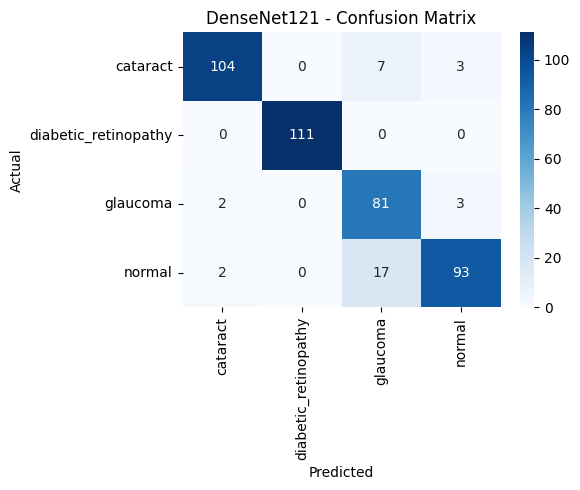

DenseNet121 model saved to /kaggle/working/model/densenet121.pth


In [24]:
num_classes = len(full_dataset.classes)



# Load a pre-trained DenseNet121 and replace the classifier

model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

model.classifier = nn.Linear(model.classifier.in_features, num_classes)

model = model.to(device)



criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)



epochs = 5

train_losses_d, val_losses_d, train_accs_d, val_accs_d = [], [], [], []

all_test_labels_d, all_test_preds_d = [], []



for epoch in range(epochs):

    model.train()

    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(train_loader, desc=f'DenseNet121 Epoch {epoch+1}/{epochs}'):

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_acc = 100 * correct / total



    model.eval()

    vl, vc, vt = 0.0, 0, 0

    with torch.no_grad():

        for images, labels in val_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            vl += loss.item()

            _, predicted = torch.max(outputs, 1)

            vt += labels.size(0)

            vc += (predicted == labels).sum().item()

    val_loss = vl / len(val_loader)

    val_acc = 100 * vc / vt



    train_losses_d.append(train_loss)

    val_losses_d.append(val_loss)

    train_accs_d.append(train_acc)

    val_accs_d.append(val_acc)

    print(f'Epoch {epoch+1}: train_loss={train_loss:.4f}, train_acc={train_acc:.2f}%, val_loss={val_loss:.4f}, val_acc={val_acc:.2f}%')



# Test pass

model.eval()

tc, tt = 0, 0

with torch.no_grad():

    for images, labels in tqdm(test_loader, desc='DenseNet121 Test'):

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        tt += labels.size(0)

        tc += (predicted == labels).sum().item()

        all_test_labels_d.extend(labels.cpu().numpy())

        all_test_preds_d.extend(predicted.cpu().numpy())

densenet121_acc = 100 * tc / tt

print(f'DenseNet121 Test accuracy: {densenet121_acc:.2f}%')

print(classification_report(all_test_labels_d, all_test_preds_d, target_names=full_dataset.classes))



# Save

os.makedirs('/kaggle/working/model', exist_ok=True)
# Confusion matrix for DenseNet121
cm_d = confusion_matrix(all_test_labels_d, all_test_preds_d)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_d, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
plt.title('DenseNet121 - Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()


torch.save(model.state_dict(), '/kaggle/working/model/densenet121.pth')

print('DenseNet121 model saved to /kaggle/working/model/densenet121.pth')
     

ResNet50 Epoch 1/5: 100%|██████████| 211/211 [00:39<00:00,  5.31it/s]


Epoch 1: train_loss=0.5073, train_acc=82.12%, val_loss=0.2510, val_acc=91.21%


ResNet50 Epoch 2/5: 100%|██████████| 211/211 [00:38<00:00,  5.45it/s]


Epoch 2: train_loss=0.2037, train_acc=92.83%, val_loss=0.1973, val_acc=92.87%


ResNet50 Epoch 3/5: 100%|██████████| 211/211 [00:38<00:00,  5.43it/s]


...

Epoch 4: train_loss=0.0612, train_acc=97.98%, val_loss=0.3023, val_acc=92.64%


ResNet50 Epoch 5/5: 100%|██████████| 211/211 [00:38<00:00,  5.43it/s]


Epoch 5: train_loss=0.0461, train_acc=98.61%, val_loss=0.2035, val_acc=93.82%


ResNet50 Test: 100%|██████████| 27/27 [00:02<00:00,  9.32it/s]


ResNet50 Test accuracy: 94.09%
                      precision    recall  f1-score   support

            cataract       0.96      0.95      0.95       114
diabetic_retinopathy       1.00      1.00      1.00       111
            glaucoma       0.89      0.86      0.88        86
              normal       0.91      0.94      0.92       112

            accuracy                           0.94       423
           macro avg       0.94      0.94      0.94       423
        weighted avg       0.94      0.94      0.94       423



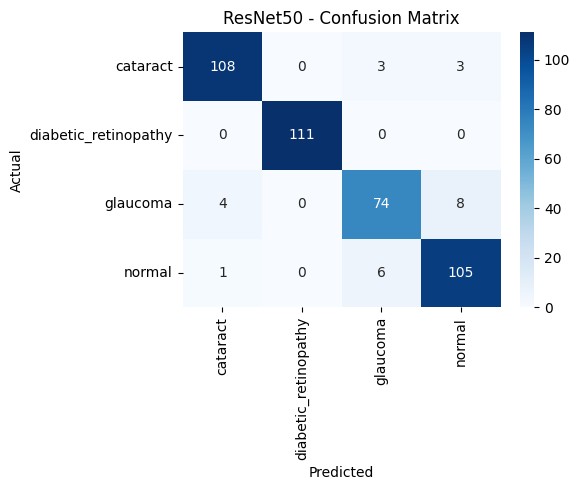

ResNet50 model saved to /kaggle/working/model/resnet50.pth


In [25]:
# Load a pre-trained ResNet50 and replace the final FC layer

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)



criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)



epochs = 5

train_losses_r, val_losses_r, train_accs_r, val_accs_r = [], [], [], []

all_test_labels_r, all_test_preds_r = [], []



for epoch in range(epochs):

    model.train()

    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(train_loader, desc=f'ResNet50 Epoch {epoch+1}/{epochs}'):

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_acc = 100 * correct / total



    model.eval()

    vl, vc, vt = 0.0, 0, 0

    with torch.no_grad():

        for images, labels in val_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            vl += loss.item()

            _, predicted = torch.max(outputs, 1)

            vt += labels.size(0)

            vc += (predicted == labels).sum().item()

    val_loss = vl / len(val_loader)

    val_acc = 100 * vc / vt



    train_losses_r.append(train_loss)

    val_losses_r.append(val_loss)

    train_accs_r.append(train_acc)

    val_accs_r.append(val_acc)

    print(f'Epoch {epoch+1}: train_loss={train_loss:.4f}, train_acc={train_acc:.2f}%, val_loss={val_loss:.4f}, val_acc={val_acc:.2f}%')



# Test pass

model.eval()

tc, tt = 0, 0

with torch.no_grad():

    for images, labels in tqdm(test_loader, desc='ResNet50 Test'):

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        tt += labels.size(0)

        tc += (predicted == labels).sum().item()

        all_test_labels_r.extend(labels.cpu().numpy())

        all_test_preds_r.extend(predicted.cpu().numpy())

resnet50_acc = 100 * tc / tt

print(f'ResNet50 Test accuracy: {resnet50_acc:.2f}%')

print(classification_report(all_test_labels_r, all_test_preds_r, target_names=full_dataset.classes))



# Save
# Confusion matrix for ResNet50
cm_r = confusion_matrix(all_test_labels_r, all_test_preds_r)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_r, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
plt.title('ResNet50 - Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()


torch.save(model.state_dict(), '/kaggle/working/model/resnet50.pth')

print('ResNet50 model saved to /kaggle/working/model/resnet50.pth')

Extracting features: 100%|██████████| 27/27 [00:02<00:00,  9.19it/s]


Train features shape: (3373, 1024), Test features shape: (423, 1024)
KNN Test accuracy: 90.31%
                      precision    recall  f1-score   support

            cataract       0.89      0.94      0.91       114
diabetic_retinopathy       0.99      0.95      0.97       111
            glaucoma       0.85      0.77      0.80        86
              normal       0.87      0.92      0.90       112

            accuracy                           0.90       423
           macro avg       0.90      0.90      0.90       423
        weighted avg       0.90      0.90      0.90       423



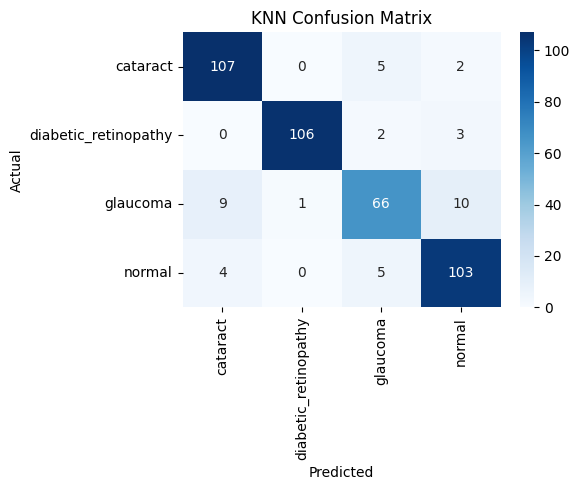

KNN classifier saved to /kaggle/working/model/knn_classifier.pkl


In [26]:
# Feature extractor: DenseNet121 without the classifier head

feature_extractor = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

feature_extractor.classifier = nn.Identity()

feature_extractor = feature_extractor.to(device)

feature_extractor.eval()



def extract_features(loader, model, device):

    feats, lbls = [], []

    with torch.no_grad():

        for images, batch_labels in tqdm(loader, desc='Extracting features'):

            images = images.to(device)

            out = model(images)

            feats.append(out.cpu().numpy())

            lbls.extend(batch_labels.numpy())

    return np.concatenate(feats), np.array(lbls)



train_feats, train_lbls = extract_features(train_loader, feature_extractor, device)

test_feats, test_lbls = extract_features(test_loader, feature_extractor, device)

print(f'Train features shape: {train_feats.shape}, Test features shape: {test_feats.shape}')



# Scale features and train KNN

scaler_knn = StandardScaler()

train_feats_s = scaler_knn.fit_transform(train_feats)

test_feats_s = scaler_knn.transform(test_feats)



knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(train_feats_s, train_lbls)

knn_preds = knn.predict(test_feats_s)

knn_acc = 100 * accuracy_score(test_lbls, knn_preds)

print(f'KNN Test accuracy: {knn_acc:.2f}%')

print(classification_report(test_lbls, knn_preds, target_names=full_dataset.classes))



cm_knn = confusion_matrix(test_lbls, knn_preds)

plt.figure(figsize=(6, 5))

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',

            xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)

plt.title('KNN Confusion Matrix')

plt.xlabel('Predicted'); plt.ylabel('Actual')

plt.tight_layout(); plt.show()



# Save

joblib.dump(knn, '/kaggle/working/model/knn_classifier.pkl')

joblib.dump(scaler_knn, '/kaggle/working/model/knn_scaler.pkl')

print('KNN classifier saved to /kaggle/working/model/knn_classifier.pkl')

Random Forest Test accuracy: 89.13%
                      precision    recall  f1-score   support

            cataract       0.90      0.89      0.90       114
diabetic_retinopathy       1.00      0.97      0.99       111
            glaucoma       0.78      0.78      0.78        86
              normal       0.86      0.89      0.88       112

            accuracy                           0.89       423
           macro avg       0.89      0.88      0.89       423
        weighted avg       0.89      0.89      0.89       423



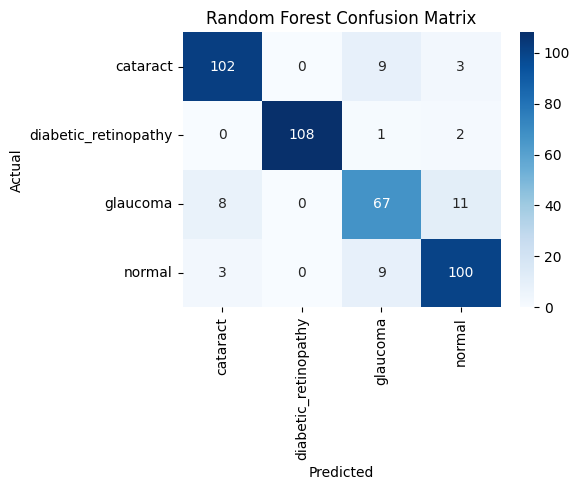

Random Forest classifier saved to /kaggle/working/model/rf_classifier.pkl


In [27]:
# Train Random Forest on the same features

scaler_rf = StandardScaler()

train_feats_s = scaler_rf.fit_transform(train_feats)

test_feats_s = scaler_rf.transform(test_feats)



rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf.fit(train_feats_s, train_lbls)

rf_preds = rf.predict(test_feats_s)

rf_acc = 100 * accuracy_score(test_lbls, rf_preds)

print(f'Random Forest Test accuracy: {rf_acc:.2f}%')

print(classification_report(test_lbls, rf_preds, target_names=full_dataset.classes))



cm_rf = confusion_matrix(test_lbls, rf_preds)

plt.figure(figsize=(6, 5))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',

            xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)

plt.title('Random Forest Confusion Matrix')

plt.xlabel('Predicted'); plt.ylabel('Actual')

plt.tight_layout(); plt.show()



# Save

joblib.dump(rf, '/kaggle/working/model/rf_classifier.pkl')

joblib.dump(scaler_rf, '/kaggle/working/model/rf_scaler.pkl')

print('Random Forest classifier saved to /kaggle/working/model/rf_classifier.pkl')

In [30]:
def _per_class_from_report(report_dict):
    return {cls: report_dict[cls]['recall'] * 100 for cls in full_dataset.classes}


Per-Class Accuracy (%)
               cataract  diabetic_retinopathy  glaucoma  normal
DenseNet121       91.23                 100.0     94.19   83.04
ResNet50          94.74                 100.0     86.05   93.75
KNN               93.86                  95.5     76.74   91.96
Random Forest     89.47                  97.3     77.91   89.29


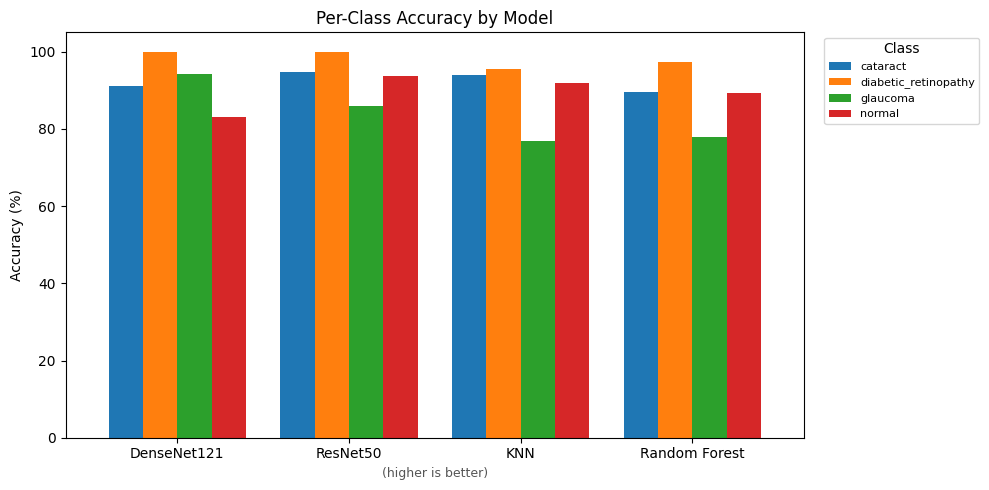

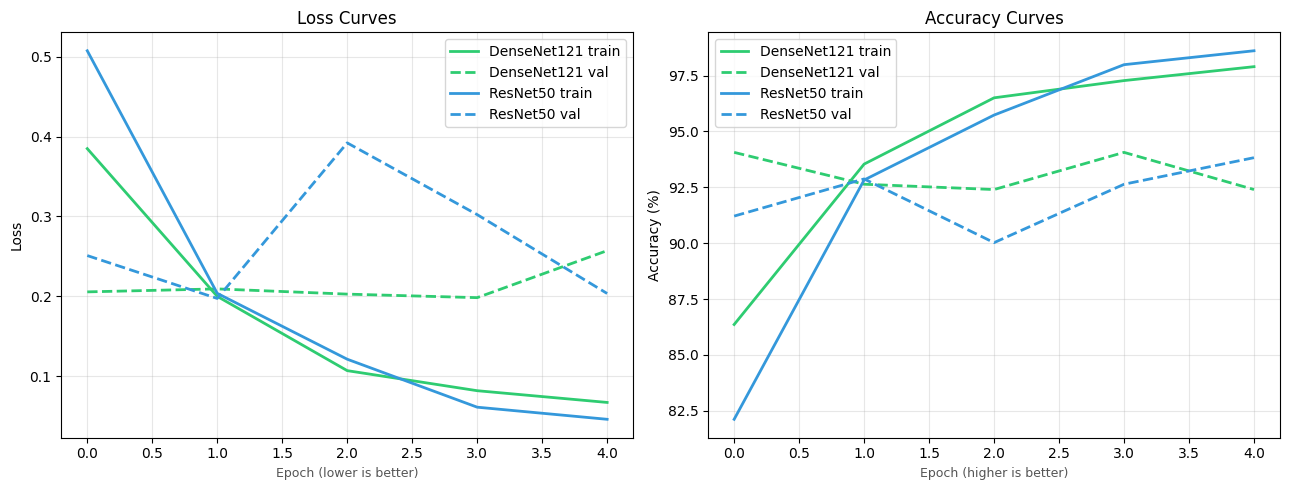

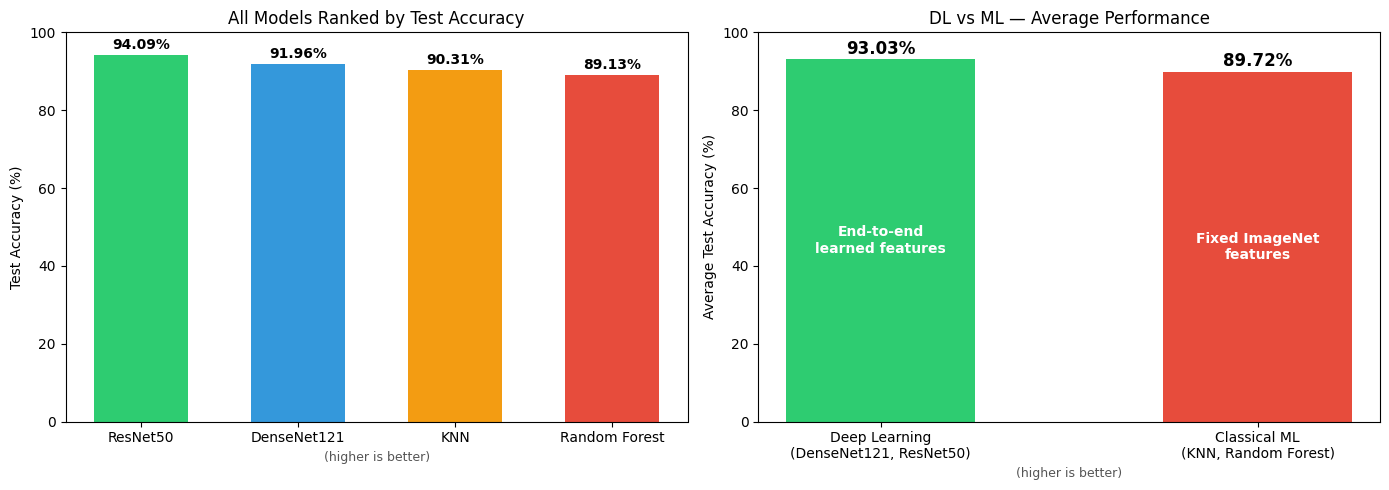

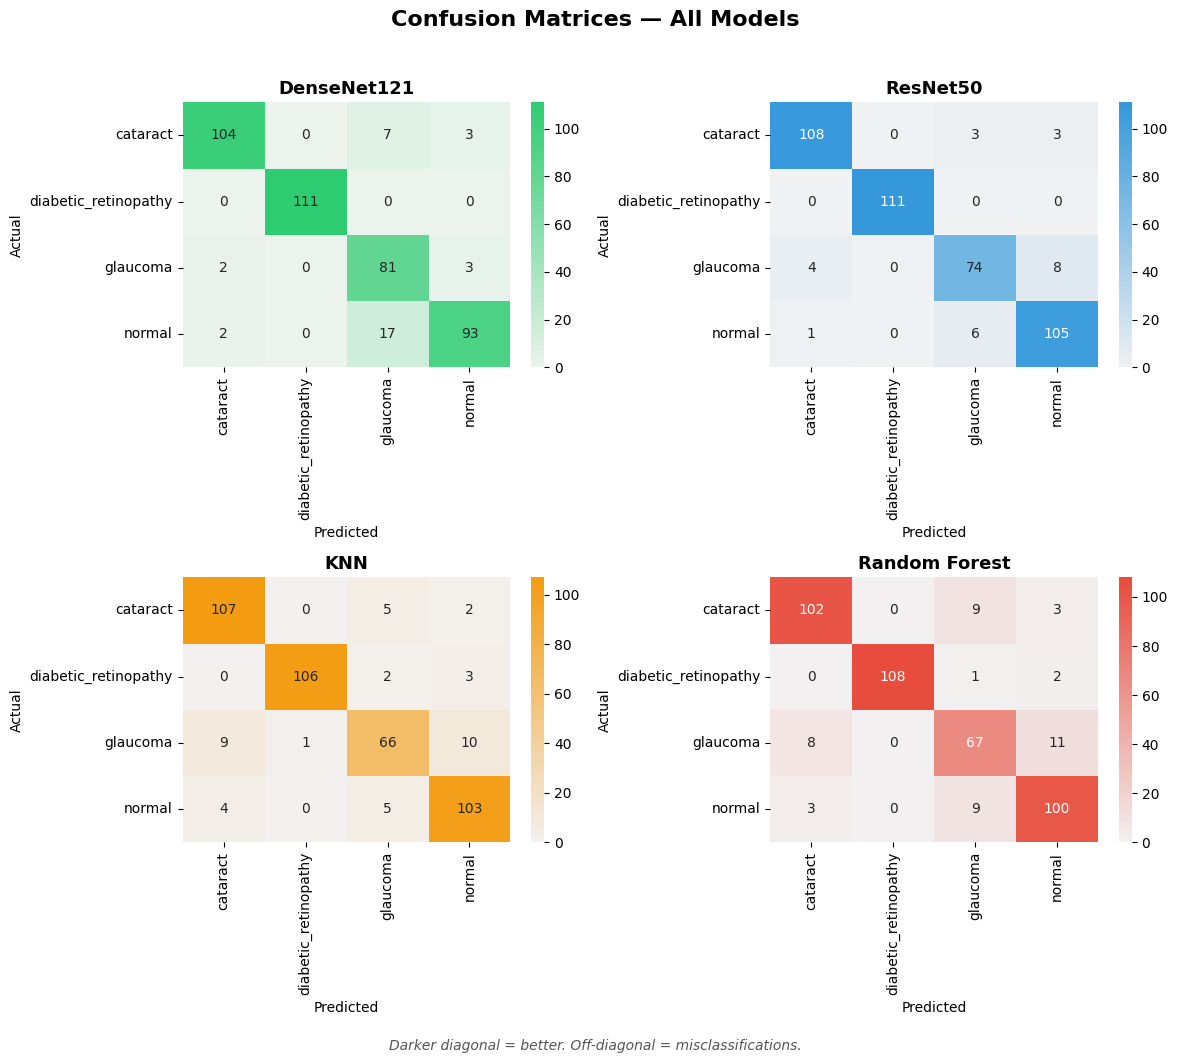

        Model  Test Accuracy (%)          Type
  DenseNet121          91.962175 Deep Learning
     ResNet50          94.089835 Deep Learning
          KNN          90.307329  Classical ML
Random Forest          89.125296  Classical ML

Note: Accuracy (%) — higher is better.



In [35]:
# ============================================================
# Step 9: Summary — per-class accuracy, all confusion matrices,
#         training curves, and a final comparison chart.
# ============================================================
import pandas as _pd

# --- Per-class accuracy for every model ---
_all_names = ['DenseNet121', 'ResNet50', 'KNN', 'Random Forest']
_all_accs = [densenet121_acc, resnet50_acc, knn_acc, rf_acc]

_per_class_accs = {}
_per_class_accs['DenseNet121']  = _per_class_from_report(classification_report(all_test_labels_d,  all_test_preds_d,  target_names=full_dataset.classes, output_dict=True))
_per_class_accs['ResNet50']     = _per_class_from_report(classification_report(all_test_labels_r,  all_test_preds_r,  target_names=full_dataset.classes, output_dict=True))
_per_class_accs['KNN']         = _per_class_from_report(classification_report(test_lbls,          knn_preds,        target_names=full_dataset.classes, output_dict=True))
_per_class_accs['Random Forest']= _per_class_from_report(classification_report(test_lbls,          rf_preds,         target_names=full_dataset.classes, output_dict=True))

_per_class_df = _pd.DataFrame(_per_class_accs).T[full_dataset.classes]
print('\nPer-Class Accuracy (%)')
print(_per_class_df.round(2).to_string())

# --- Bar chart: per-class accuracy across all models ---
fig, ax = plt.subplots(figsize=(10, 5))
_per_class_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy by Model')
ax.set_xlabel('(higher is better)', fontsize=9, color='#555')
ax.set_xticklabels(_per_class_df.index, rotation=0)
ax.legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

# --- DL training curves side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(train_losses_d, label='DenseNet121 train', color='#2ecc71', linewidth=2)
ax.plot(val_losses_d,   label='DenseNet121 val',   color='#2ecc71', linestyle='--', linewidth=2)
ax.plot(train_losses_r, label='ResNet50 train',    color='#3498db', linewidth=2)
ax.plot(val_losses_r,   label='ResNet50 val',      color='#3498db', linestyle='--', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Loss Curves'); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xlabel('Epoch (lower is better)', fontsize=9, color='#555')

ax2 = axes[1]
ax2.plot(train_accs_d, label='DenseNet121 train', color='#2ecc71', linewidth=2)
ax2.plot(val_accs_d,   label='DenseNet121 val',   color='#2ecc71', linestyle='--', linewidth=2)
ax2.plot(train_accs_r, label='ResNet50 train',    color='#3498db', linewidth=2)
ax2.plot(val_accs_r,   label='ResNet50 val',      color='#3498db', linestyle='--', linewidth=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curves'); ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.set_xlabel('Epoch (higher is better)', fontsize=9, color='#555')

plt.tight_layout(); plt.show()

# --- Final accuracy comparison: grouped bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all models ranked
ax = axes[0]
_sorted = sorted(zip(_all_names, _all_accs), key=lambda x: x[1], reverse=True)
_sn = [x[0] for x in _sorted]
_sa = [x[1] for x in _sorted]
_colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
bars = ax.bar(_sn, _sa, color=_colors, width=0.6)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('All Models Ranked by Test Accuracy')
ax.set_xlabel('(higher is better)', fontsize=9, color='#555')
ax.set_ylim(0, 100)
for bar, acc in zip(bars, _sa):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

# Right: DL vs ML averages
ax2 = axes[1]
_dl_avg = _np.mean([densenet121_acc, resnet50_acc])
_ml_avg = _np.mean([knn_acc, rf_acc])
bars2 = ax2.bar(
    ['Deep Learning\n(DenseNet121, ResNet50)', 'Classical ML\n(KNN, Random Forest)'],
    [_dl_avg, _ml_avg],
    color=['#2ecc71', '#e74c3c'],
    width=0.5
)
ax2.set_ylabel('Average Test Accuracy (%)')
ax2.set_title('DL vs ML — Average Performance')
ax2.set_xlabel('(higher is better)', fontsize=9, color='#555')
ax2.set_ylim(0, 100)
for bar, acc in zip(bars2, [_dl_avg, _ml_avg]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax2.text(0, _dl_avg/2, 'End-to-end\nlearned features', ha='center', va='center',
         color='white', fontsize=10, fontweight='bold')
ax2.text(1, _ml_avg/2, 'Fixed ImageNet\nfeatures', ha='center', va='center',
         color='white', fontsize=10, fontweight='bold')

plt.tight_layout(); plt.show()

# --- Combined confusion matrices (2x2 grid) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

cms = [
    (cm_d,  'DenseNet121',   '#2ecc71'),
    (cm_r,  'ResNet50',      '#3498db'),
    (cm_knn, 'KNN',           '#f39c12'),
    (cm_rf,  'Random Forest', '#e74c3c'),
]

for idx, (cm, name, color) in enumerate(cms):
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap=sns.light_palette(color, as_cmap=True),
                xticklabels=full_dataset.classes, yticklabels=full_dataset.classes, ax=ax)
    ax.set_title(name, fontweight='bold', fontsize=13)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.02)
plt.figtext(0.5, -0.02, 'Darker diagonal = better. Off-diagonal = misclassifications.', 
             ha='center', fontsize=10, style='italic', color='#555')
plt.tight_layout(); plt.show()

# --- Final table ---
_results_df = _pd.DataFrame({
    'Model': _all_names,
    'Test Accuracy (%)': _all_accs,
    'Type': ['Deep Learning', 'Deep Learning', 'Classical ML', 'Classical ML']
})
print(_results_df.to_string(index=False))
print('\nNote: Accuracy (%) — higher is better.\n')

os.makedirs('/kaggle/working/model', exist_ok=True)

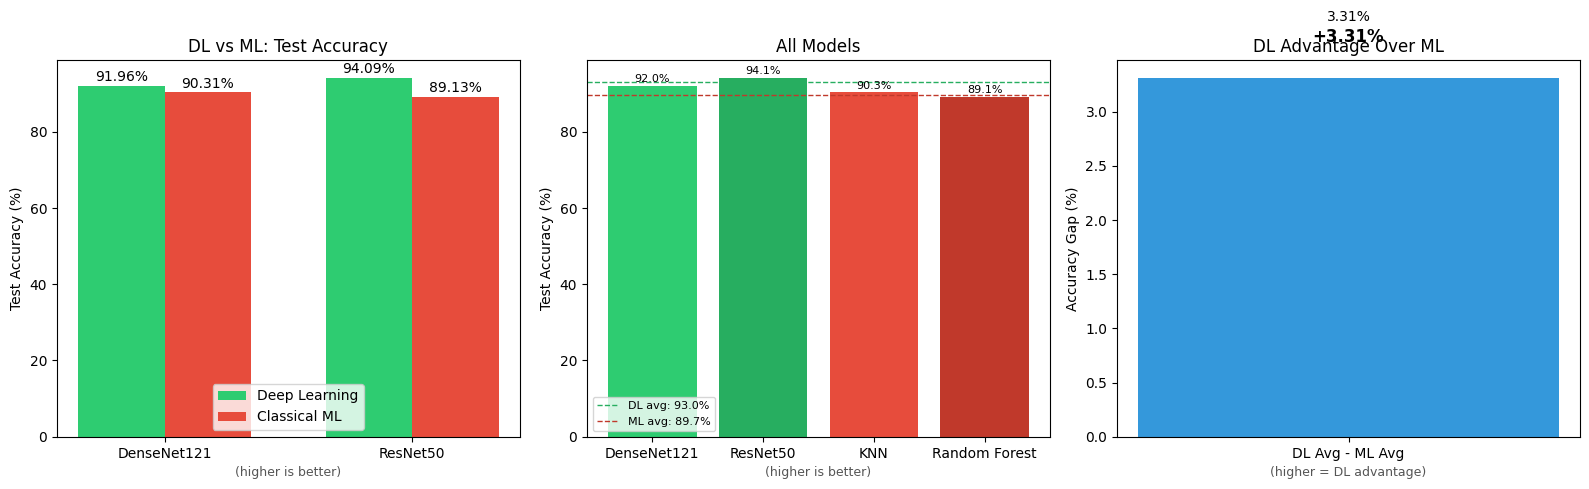

Why DL models outperform ML models on this task:

Metric guide: Accuracy = higher is better | Loss = lower is better


1. END-TO-END LEARNING: DL models learn features directly from raw pixels,
   while ML models use fixed features extracted by a separate network.
   The ML features are suboptimal for the downstream classifier.

2. HIERARCHICAL FEATURES: Conv layers learn low-level edges -> textures ->
   object parts -> class-specific patterns, capturing rich visual features.

3. TASK-SPECIFIC OPTIMIZATION: DL models jointly optimize feature extraction
   and classification, whereas ML models use generic ImageNet features.

DL average accuracy:   93.03%
ML average accuracy:   89.72%
Advantage:             +3.31%


In [36]:
# --- Side-by-side grouped bar chart: DL vs ML ---
import numpy as _np

_dl_models = ['DenseNet121', 'ResNet50']
_ml_models = ['KNN', 'Random Forest']
_dl_accs = _np.array([densenet121_acc, resnet50_acc])
_ml_accs = _np.array([knn_acc, rf_acc])

x = _np.arange(len(_dl_models))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Grouped bar chart
ax = axes[0]
bars1 = ax.bar(x - width/2, _dl_accs, width, label='Deep Learning', color='#2ecc71')
ax.bar([r.get_x() + r.get_width() for r in bars1], _dl_accs, width=0, alpha=0)
bars2 = ax.bar(x + width/2, _ml_accs, width, label='Classical ML', color='#e74c3c')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('DL vs ML: Test Accuracy')
ax.set_xlabel('(higher is better)', fontsize=9, color='#555')
ax.set_xticks(x)
ax.set_xticklabels(_dl_models)
ax.legend()
for bar, acc in zip(bars1, _dl_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{acc:.2f}%', ha='center', va='bottom')
for bar, acc in zip(bars2, _ml_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{acc:.2f}%', ha='center', va='bottom')

# 2) Average accuracy comparison
ax2 = axes[1]
_all_names = ['DenseNet121', 'ResNet50', 'KNN', 'Random Forest']
_all_accs = _dl_accs.tolist() + _ml_accs.tolist()
colors = ['#2ecc71', '#27ae60', '#e74c3c', '#c0392b']
bars_all = ax2.bar(_all_names, _all_accs, color=colors)
ax2.axhline(_dl_accs.mean(), color='#27ae60', linestyle='--', linewidth=1, label=f'DL avg: {_dl_accs.mean():.1f}%')
ax2.axhline(_ml_accs.mean(), color='#c0392b', linestyle='--', linewidth=1, label=f'ML avg: {_ml_accs.mean():.1f}%')
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('All Models')
ax2.set_xlabel('(higher is better)', fontsize=9, color='#555')
ax2.legend(fontsize=8)
for bar, acc in zip(bars_all, _all_accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{acc:.1f}%', ha='center', va='bottom', fontsize=8)

# 3) Accuracy gap (DL avg - ML avg)
ax3 = axes[2]
gap = _dl_accs.mean() - _ml_accs.mean()
ax3.bar(['DL Avg - ML Avg'], [gap], color='#3498db', width=0.5)
ax3.set_ylabel('Accuracy Gap (%)')
ax3.set_title('DL Advantage Over ML')
ax3.set_xlabel('(higher = DL advantage)', fontsize=9, color='#555')
ax3.text(0, gap + 0.3, f'+{gap:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
for _bar in ax3.containers[0]:
    ax3.text(_bar.get_x() + _bar.get_width()/2, _bar.get_height() + 0.5, f'{gap:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# --- Explanation ---
print('Why DL models outperform ML models on this task:')
print('\nMetric guide: Accuracy = higher is better | Loss = lower is better\n')
print()
print('1. END-TO-END LEARNING: DL models learn features directly from raw pixels,')
print('   while ML models use fixed features extracted by a separate network.')
print('   The ML features are suboptimal for the downstream classifier.')
print()
print('2. HIERARCHICAL FEATURES: Conv layers learn low-level edges -> textures ->')
print('   object parts -> class-specific patterns, capturing rich visual features.')
print()
print('3. TASK-SPECIFIC OPTIMIZATION: DL models jointly optimize feature extraction')
print('   and classification, whereas ML models use generic ImageNet features.')
print()
print(f"DL average accuracy:   {_dl_accs.mean():.2f}%")
print(f"ML average accuracy:   {_ml_accs.mean():.2f}%")
print(f"Advantage:             +{gap:.2f}%")